## Clustering & Principal Component Analysis (PCA) 
 Unsupervised Learning

 Unlike supervised learning methods, which use hurricane categories as the target variable, unsupervised learning explores the data without predefined labels to identify natural patterns and relationships among storms. Building on the completed data preprocessing and exploratory data analysis, K-Means clustering and Hierarchical Clustering were applied to group hurricanes based on similarities in their physical and environmental characteristics, including atmospheric pressure, storm size, and geographic location. Principal Component Analysis (PCA) was then performed to reduce the dimensionality of the dataset while preserving as much information as possible, allowing the cluster structure to be visualized in two dimensions. These techniques provide additional insight into hurricane behavior and help determine whether storms naturally form distinct groups based on their observed characteristics rather than their assigned hurricane categories.

### Import Libraries

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [19]:
hurricanes = pd.read_csv("cleaned_data.csv")
print(hurricanes.columns)

Index(['name', 'year', 'month', 'day', 'hour', 'lat', 'long', 'status',
       'category', 'wind', 'pressure', 'tropicalstorm_force_diameter',
       'hurricane_force_diameter', 'hurricane_class'],
      dtype='object')


**K-Means Clustering**

K-Means clustering was applied to identify natural groupings of hurricanes based on similarities in their environmental and physical characteristics. 
Unlike supervised learning methods, K-Means does not use hurricane category labels; instead, it partitions observations into clusters by minimizing the distance between observations and their assigned cluster centers. 
Before clustering, all variables were standardized to ensure that differences in measurement scales did not influence the clustering results.

In [12]:
# Select Features
# Variables selected from the EDA
cluster_data = hurricanes[
    [
        'pressure',
        'hurricane_force_diameter',
        'tropicalstorm_force_diameter',
        'lat',
        'long'
    ]
].copy()

In [17]:
# Missing Values
cluster_data = cluster_data.fillna(cluster_data.median())

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

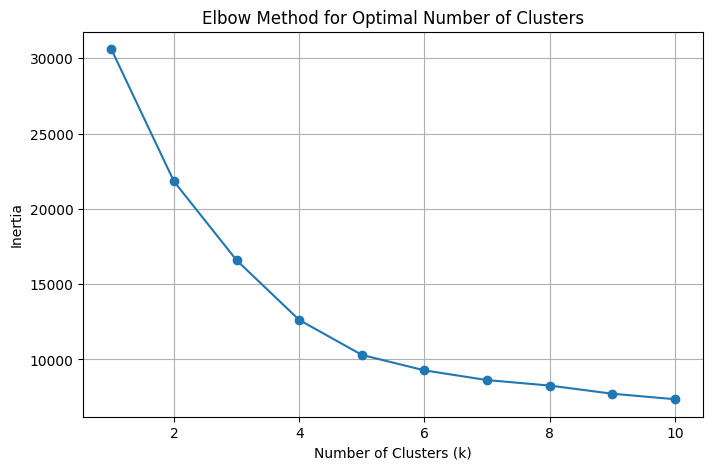

In [18]:
# Elbow Method
# Determine the Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

The Elbow Method was used to determine the optimal number of clusters by examining the relationship between the number of clusters and the within-cluster sum of squares (inertia). The curve begins to level off at approximately k = 5, indicating diminishing returns from adding additional clusters. Therefore, five clusters were selected for the K-Means analysis because they provide a good balance between model simplicity and cluster separation.

In [20]:
# Fit the K-Means Model

from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=5,         # Replace no. of clusters with (k) above
    random_state=42,
    n_init=10
)
cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)

# Number of hurricanes in each cluster
cluster_data["Cluster"].value_counts().sort_index()

Cluster
0    1413
1    1260
2    1002
3     544
4     881
Name: count, dtype: int64

The K-Means algorithm successfully partitioned the hurricane observations into five distinct clusters. The clusters are not perfectly equal in size, which is expected because K-Means groups observations based on similarity rather than forcing equal-sized groups.

Cluster 0 contains the largest number of observations (1,413), suggesting that many hurricanes share similar environmental and physical characteristics. Cluster 3 is the smallest cluster (544 observations), indicating a more specialized group of storms with distinct characteristics. The remaining clusters contain between 881 and 1,260 observations, demonstrating that the hurricane data naturally forms several meaningful groupings.

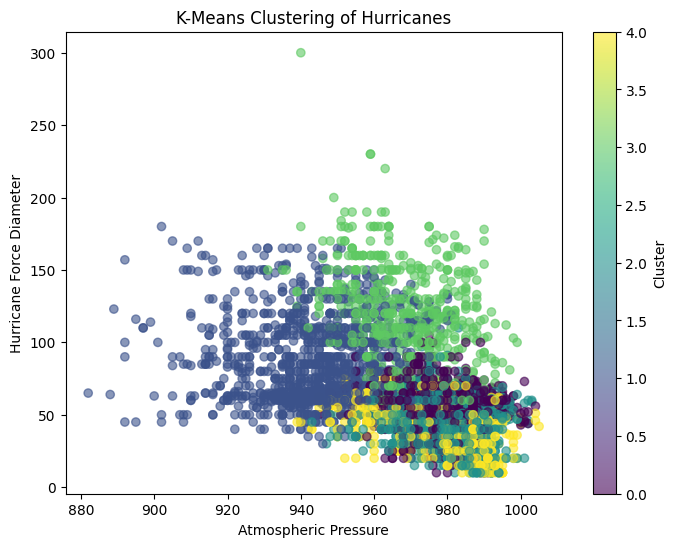

In [21]:
# Visualize the K-Means Clusters

plt.figure(figsize=(8,6))

plt.scatter(
    cluster_data["pressure"],
    cluster_data["hurricane_force_diameter"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("K-Means Clustering of Hurricanes")
plt.xlabel("Atmospheric Pressure")
plt.ylabel("Hurricane Force Diameter")
plt.colorbar(label="Cluster")

plt.show()

K-Means Cluster Visualization Interpretation

The K-Means clustering algorithm successfully grouped the hurricane observations into five distinct clusters based on similarities in atmospheric pressure, storm size measurements, and geographic location. The scatter plot illustrates how hurricanes are separated into clusters according to differences in atmospheric pressure and hurricane-force diameter.

Although some overlap exists between clusters, distinct groupings are visible. Hurricanes with larger hurricane-force diameters tend to form separate clusters from smaller storms, while atmospheric pressure also contributes to cluster separation. This suggests that hurricanes naturally organize into groups with similar physical and environmental characteristics, even without using hurricane category labels.

**What insights did clustering reveal?**

K-Means identified five natural groups of hurricanes based on atmospheric pressure, storm size, and geographic location. The clusters reveal that hurricanes with similar physical characteristics tend to group together, while storms with larger hurricane-force diameters and lower atmospheric pressures often form distinct clusters. These results demonstrate that meaningful hurricane behavior patterns can be identified without relying on predefined hurricane category labels.

**Hierarchical Clustering**

Hierarchical clustering was performed to further examine the natural grouping of hurricanes. Unlike K-Means, hierarchical clustering does not require specifying the number of clusters in advance. Instead, it builds a hierarchy of clusters by successively merging the most similar observations. The resulting dendrogram provides a visual representation of how hurricanes are grouped based on their similarities.

In [22]:
# Import Libraries for Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute the Linkage Matrix
linked = linkage(X_scaled, method='ward')

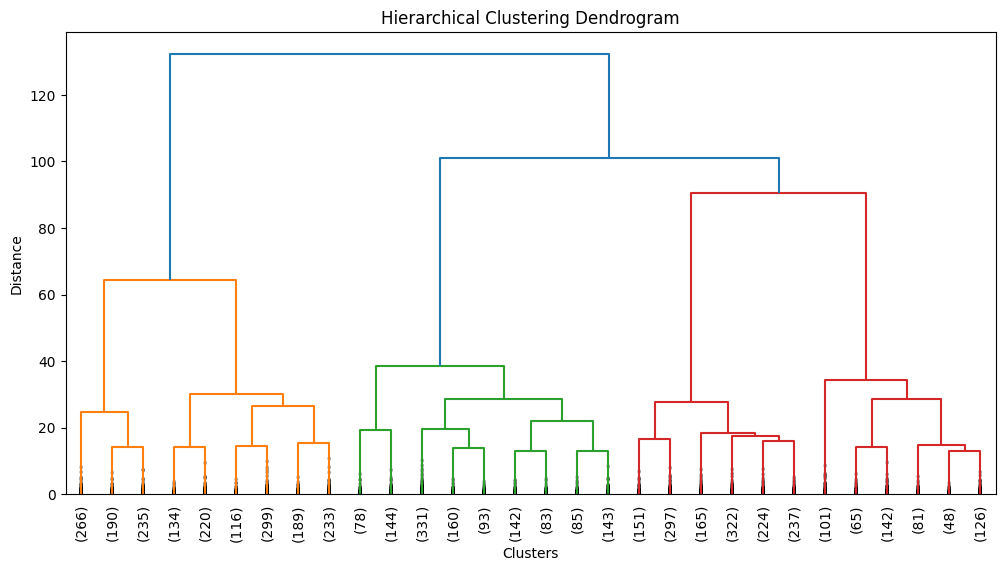

In [23]:
# Plot the Hierarchical Clustering Dendrogram

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

The hierarchical clustering dendrogram illustrates how hurricane observations are progressively merged into larger clusters based on similarities in atmospheric pressure, storm size, and geographic location. The vertical axis represents linkage distance, where shorter branches indicate more similar observations and taller branches indicate greater differences between groups.

The dendrogram reveals several distinct cluster groupings before the final merges occur, indicating that hurricanes naturally form multiple groups based on their physical characteristics. A noticeable increase in linkage distance occurs near the top of the hierarchy, suggesting that combining the final clusters would merge observations that are substantially different from one another. These findings support the K-Means results and provide additional evidence that the hurricane dataset contains meaningful underlying cluster structure.

***Why use Hierarchical Clustering if you already used K-Means?**

K-Means requires the number of clusters to be specified in advance, whereas Hierarchical Clustering builds a tree of relationships without making that assumption. The dendrogram provides a visual representation of how observations group together and serves as a validation of the cluster structure identified by K-Means.

**Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) was performed to reduce the dimensionality of the hurricane dataset while preserving as much of the original variation as possible. PCA transforms the original variables into a smaller set of uncorrelated principal components, making it easier to visualize the data and identify patterns. The principal components were then used to display the hurricane clusters identified by the K-Means algorithm in two dimensions.

In [24]:
# Import PCA
from sklearn.decomposition import PCA

# Perform Principal Component Analysis (PCA)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

In [25]:
# Calculate the Explained Variance
explained_variance = pca.explained_variance_ratio_

print("Principal Component 1:", explained_variance[0])
print("Principal Component 2:", explained_variance[1])
print("Total Explained Variance:", explained_variance.sum())

Principal Component 1: 0.4139216769868424
Principal Component 2: 0.23942376725115055
Total Explained Variance: 0.6533454442379929


The first principal component (PC1) explains 41.39% of the total variance in the hurricane dataset, while the second principal component (PC2) explains 23.94%. Together, the first two principal components account for approximately 65.33% of the total variance.

This indicates that the two principal components preserve a substantial amount of the information contained in the original variables while reducing the dataset from five dimensions to two. As a result, PCA provides an effective way to visualize the hurricane data and evaluate how well the K-Means clusters are separated in a two-dimensional space.

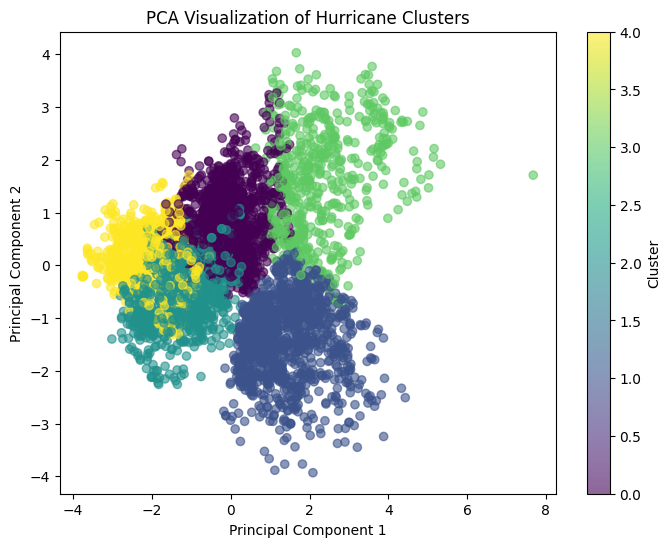

In [26]:
# PCA Scatter Plot
# Create a DataFrame with the Principal Components

import pandas as pd
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(
    principal_components,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = cluster_data["Cluster"]

# Visualize the PCA Results

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("PCA Visualization of Hurricane Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()



The PCA scatter plot displays the hurricane observations using the first two principal components, which together explain 65.33% of the total variance in the dataset. Reducing the dataset to two dimensions makes it easier to visualize the overall structure while retaining a substantial amount of the information contained in the original variables.

The visualization shows that the five K-Means clusters form several distinct groups, although some overlap is present. This overlap is expected because PCA compresses five original variables into only two principal components. Despite this reduction, the clusters remain reasonably well separated, indicating that the K-Means algorithm successfully identified meaningful patterns in the hurricane data. Overall, PCA confirms that hurricanes naturally group according to similarities in their physical and environmental characteristics.

**Conclusion**

Unsupervised learning techniques were successfully applied to identify natural patterns within the hurricane dataset. The Elbow Method suggested that five clusters provided an appropriate balance between model simplicity and cluster separation. K-Means clustering grouped hurricanes based on similarities in atmospheric pressure, storm size, and geographic location, while Hierarchical Clustering produced a dendrogram that supported the presence of multiple distinct groups. Principal Component Analysis reduced the five original variables to two principal components that explained 65.33% of the total variance, allowing the clusters to be visualized effectively. Together, these methods demonstrated that hurricanes exhibit meaningful natural groupings even without using hurricane category labels.